# Model Training, Evaluation & Feature Importance

This notebook covers the full modelling pipeline for the Steam Games Hit Prediction project.

**Prerequisites**: run `eda_workflow.ipynb` first to generate `csv_files/preprocessed_data.csv`.

Steps covered here:
1. Load the preprocessed dataset
2. Define the binary target `is_hit` and drop leaking columns
3. Engineer five aggregate features
4. Train three models with 5-fold stratified cross-validation
5. Compare results across train / validation / test splits
6. Analyse feature importance with SHAP and stability selection

---

### Why this is a hard classification problem

Only ~4% of Steam games qualify as "hits" — the dataset is severely imbalanced. Standard accuracy is misleading: a model that always predicts "not a hit" would score 96% accuracy without learning anything useful.

We therefore prioritise **PR AUC** (Precision-Recall AUC) as the primary metric. Unlike ROC AUC, PR AUC is sensitive to class imbalance and directly reflects how well the model identifies the rare positive class.

## 1. Load Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_final = pd.read_csv("csv_files/preprocessed_data.csv")
print(f"Loaded: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")

Loaded: 122,611 rows x 129 columns


## 2. Define the Target Variable

A game is classified as a **hit** (`is_hit = 1`) if it meets **both** of the following criteria:
- At least **1,000 positive reviews**
- At least **80% positive review ratio** — `Positive / (Positive + Negative) ≥ 0.8`

After constructing the target, `Positive` and `Negative` are immediately dropped. These two columns were used to define `is_hit`, so keeping them during training would constitute **data leakage** — the model would learn to predict the target directly from its source, inflating performance metrics and producing a model that fails on new data.

In [2]:
df_final['is_hit'] = np.where(
    (df_final['Positive'] >= 1000) &
    (df_final['Positive'] / (df_final['Positive'] + df_final['Negative']) >= 0.8),
    1,
    0
)

# Drop source columns to prevent data leakage
df_final = df_final.drop(columns=['Positive', 'Negative'])

class_counts = df_final['is_hit'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nHit rate: {class_counts[1] / len(df_final):.2%}")

Class distribution:
is_hit
0    117894
1      4717
Name: count, dtype: int64

Hit rate: 3.85%


C:\Users\astep\AppData\Local\Temp\ipykernel_47524\3717265777.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['is_hit'] = np.where(


## 3. Feature Engineering

Five aggregate features are derived from the existing one-hot encoded columns.

**Why add these?** Models work with raw numeric values and do not inherently understand column names. Having 58 separate `categories_*` binary flags is informationally equivalent to counting them for tree-based models, but the aggregate count gives linear models a compact, interpretable signal. The same applies to language and genre counts.

| Feature | Formula | Intuition |
|---|---|---|
| `n_languages` | sum of `supported_language_*` flags | More languages → broader potential audience |
| `n_categories` | sum of `categories_*` flags | More Steam features (co-op, achievements...) |
| `n_genres` | sum of `genres_*` flags | Genre breadth |
| `n_tags` | sum of tag flags | User-defined taxonomy depth |
| `engagement_ratio` | `Median playtime / (Avg playtime + 1)` | Near 1 = consistent engagement; near 0 = sporadic play |

In [3]:
from explore import add_engineered_features

df_final = add_engineered_features(df_final)
print(f"Dataset shape after feature engineering: {df_final.shape}")

Added columns: n_languages (11 flags), n_categories (58 flags), n_genres (33 flags), n_tags (0 flags), engagement_ratio
Dataset shape after feature engineering: (122611, 133)


## 4. Model Training with Cross-Validation

### Models

Three model families are evaluated, each representing a different approach to the problem:

| Model | Configuration | Imbalance handling |
|---|---|---|
| **Logistic Regression** | ElasticNet (`l1_ratio=0.5`), `C=1.0`, `max_iter=5000` | `class_weight='balanced'` — upweights the positive class by ~25× |
| **LightGBM** | 400 trees, `max_depth=6`, `num_leaves=63` | `is_unbalance=True` — internal class reweighting |
| **MLP** | 256 → 128 → 64, ReLU, Adam, L2=0.001, 50 epochs | `sample_weight='balanced'` — per-sample weighting during training |

### Cross-validation strategy

- **Data split**: 80% train / 20% test, stratified by `is_hit` (preserves the ~4% hit rate in both sets)
- **Cross-validation**: `StratifiedKFold(n_splits=5)` on the training set
- **Scaling**: `StandardScaler` is fit **inside each fold** on training data only — this prevents data leakage from scaling
- **Test set**: evaluated after each fold without participating in any training step

After each fold, the notebook generates:
- Confusion matrices for all three models
- SHAP beeswarm plots (LightGBM, top 15 features)
- Training history curves (MLP)

In [4]:
from classification import (
    prepare_data,
    cross_validate_models,
    plot_cv_comparison,
    shap_stability_selection,
)

SAVE_DIR = 'results/klasyfikacja'

# Prepare train/test split and extract feature names
X_train, X_test, y_train, y_test, feature_names, scaler = prepare_data(df_final)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train hit rate: {y_train.mean():.2%} | Test hit rate: {y_test.mean():.2%}")

c:\Users\astep\Documents\Steam-Game-Classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removed 1 zero-variance features.
Split: train=98088, test=24523
Class 'is_hit'=1: 3.8%  (4717/122611)
Features after zero-variance filtering: 131
Train: (98088, 131), Test: (24523, 131)
Train hit rate: 3.85% | Test hit rate: 3.85%



--- Fold 1/5 ---
  [LogReg (ElasticNet)] ...
  [LightGBM] ...
  [MLP] (30 epochs) ...
  Saved: results/klasyfikacja\cv_mlp_history_fold1.png


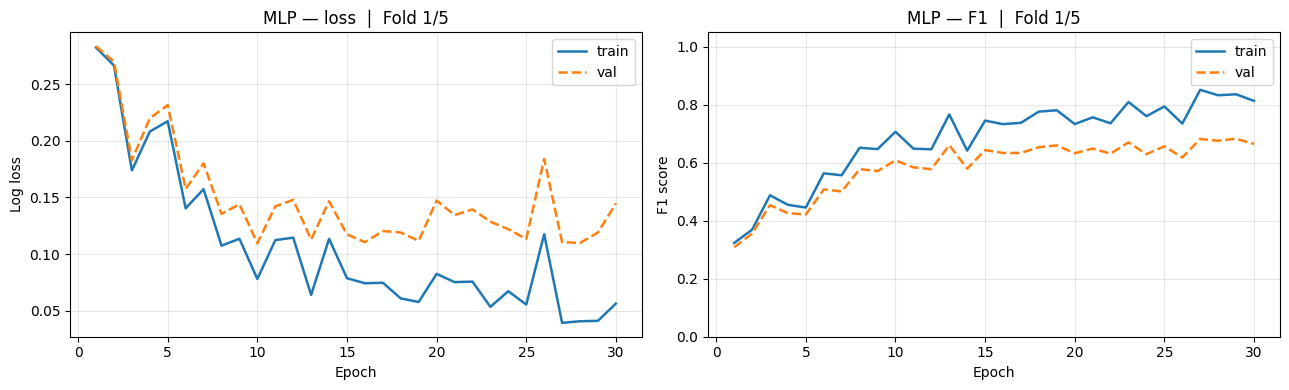

  Saved: results/klasyfikacja\cv_confusion_fold1.png


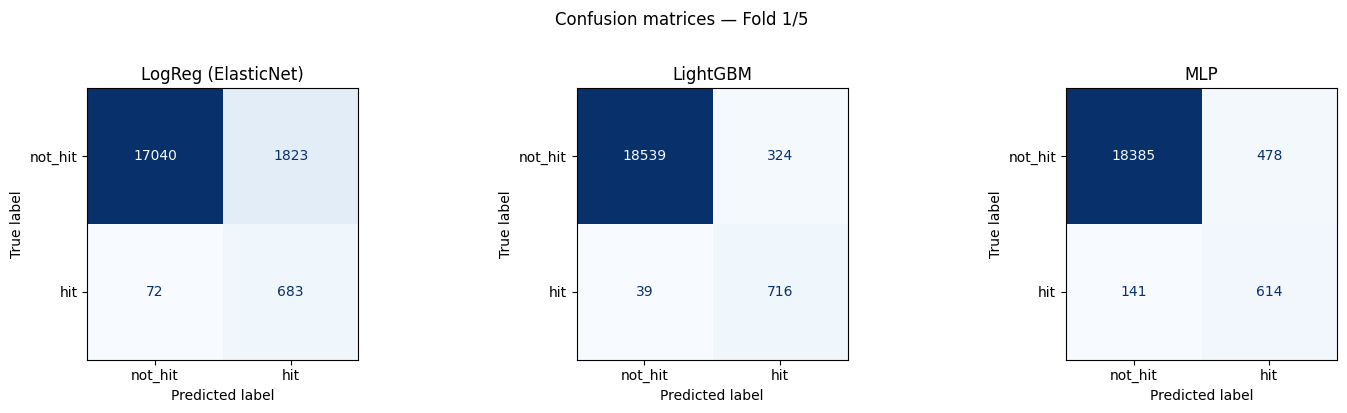

  Saved: results/klasyfikacja\cv_shap_fold1.png


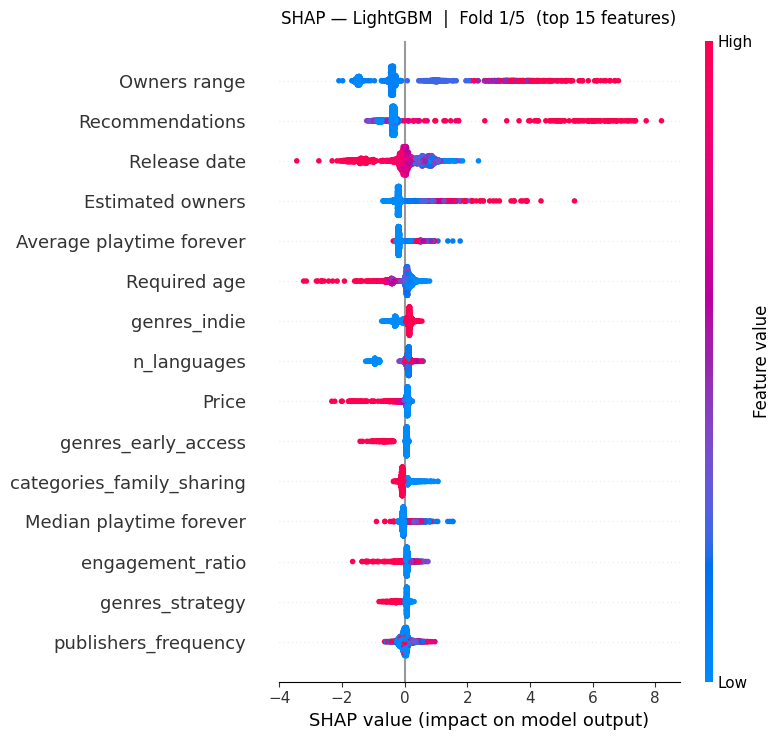


--- Fold 2/5 ---
  [LogReg (ElasticNet)] ...
  [LightGBM] ...
  [MLP] (30 epochs) ...
  Saved: results/klasyfikacja\cv_mlp_history_fold2.png


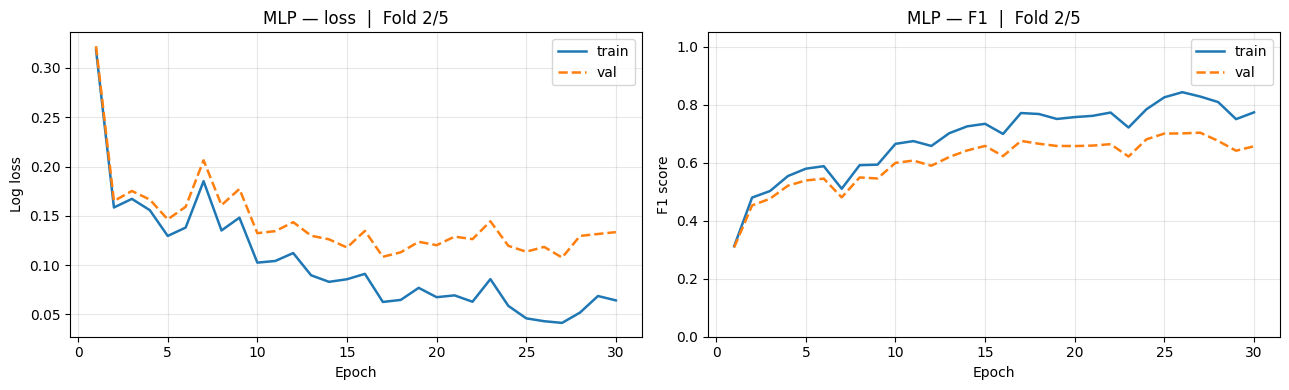

  Saved: results/klasyfikacja\cv_confusion_fold2.png


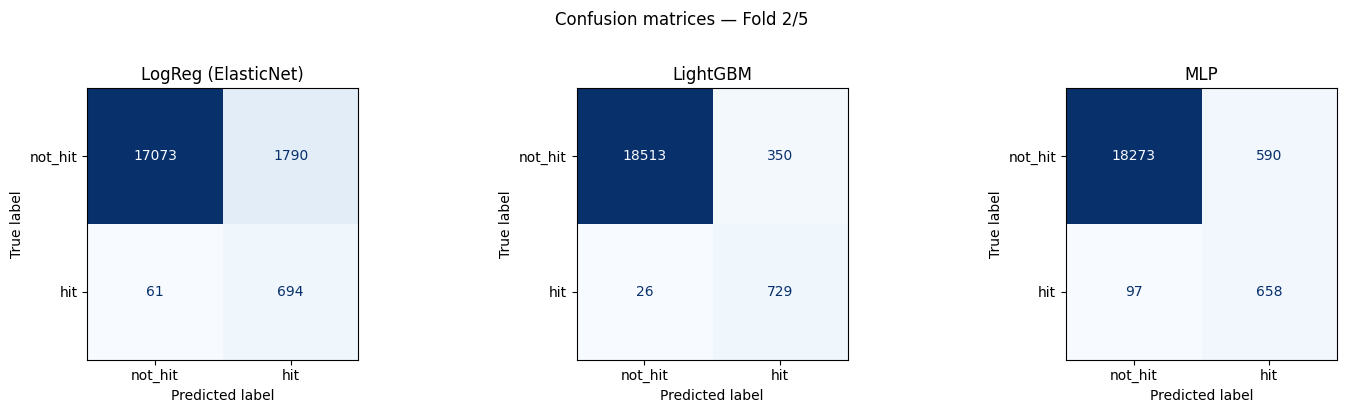

  Saved: results/klasyfikacja\cv_shap_fold2.png


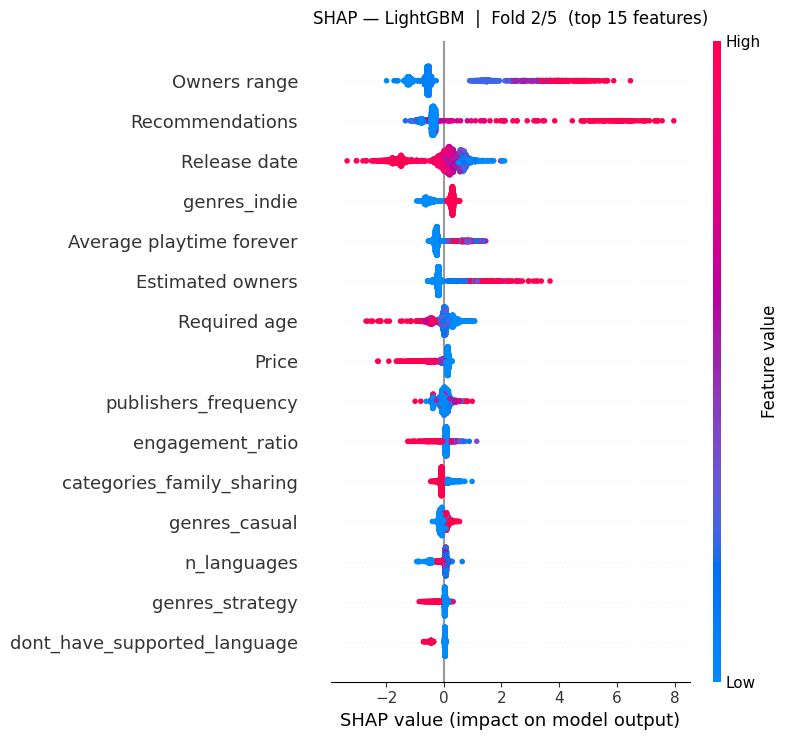


--- Fold 3/5 ---
  [LogReg (ElasticNet)] ...
  [LightGBM] ...
  [MLP] (30 epochs) ...
  Saved: results/klasyfikacja\cv_mlp_history_fold3.png


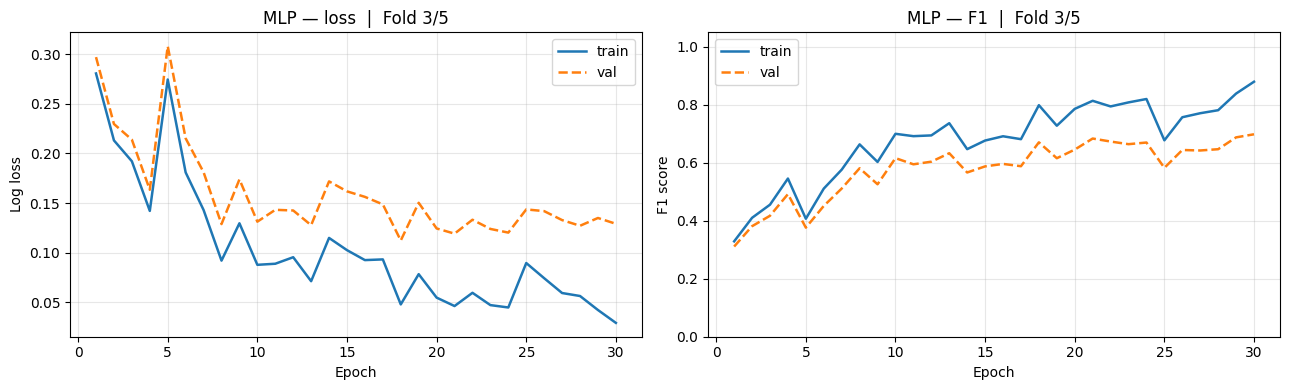

  Saved: results/klasyfikacja\cv_confusion_fold3.png


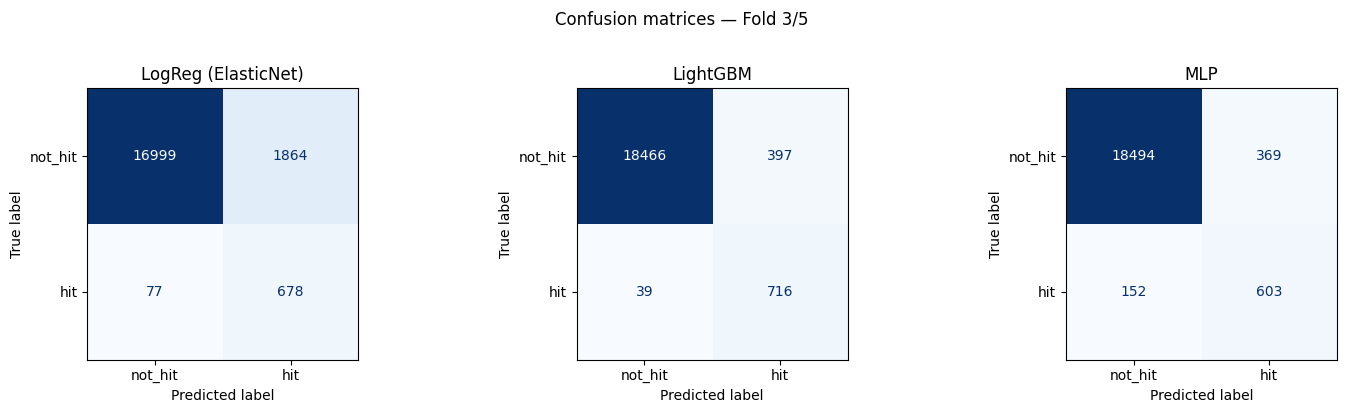

  Saved: results/klasyfikacja\cv_shap_fold3.png


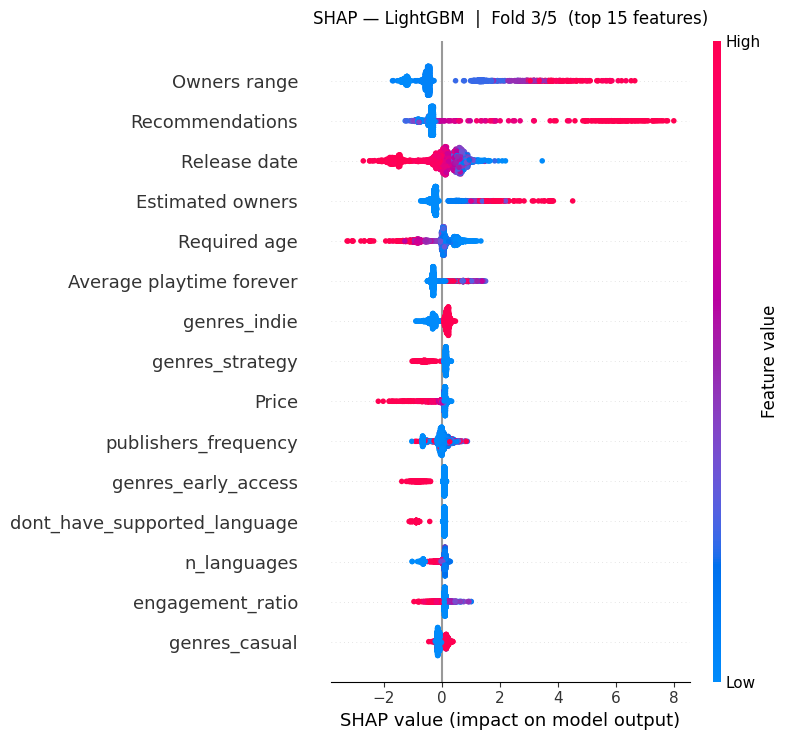


--- Fold 4/5 ---
  [LogReg (ElasticNet)] ...
  [LightGBM] ...
  [MLP] (30 epochs) ...
  Saved: results/klasyfikacja\cv_mlp_history_fold4.png


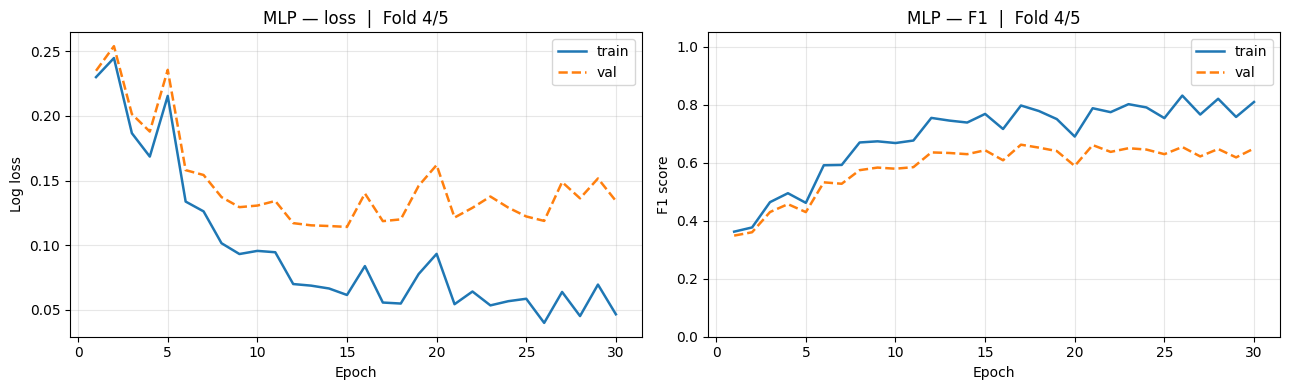

  Saved: results/klasyfikacja\cv_confusion_fold4.png


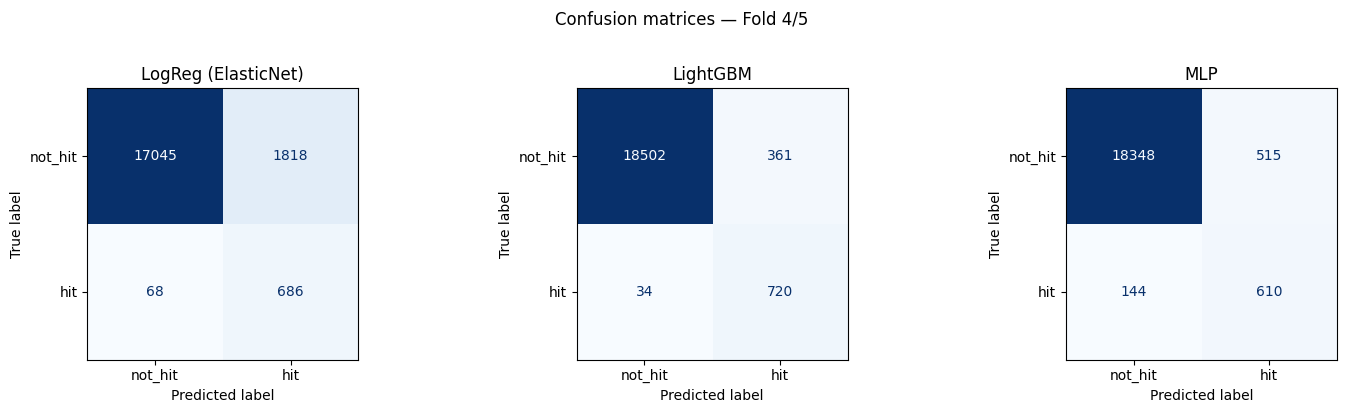

  Saved: results/klasyfikacja\cv_shap_fold4.png


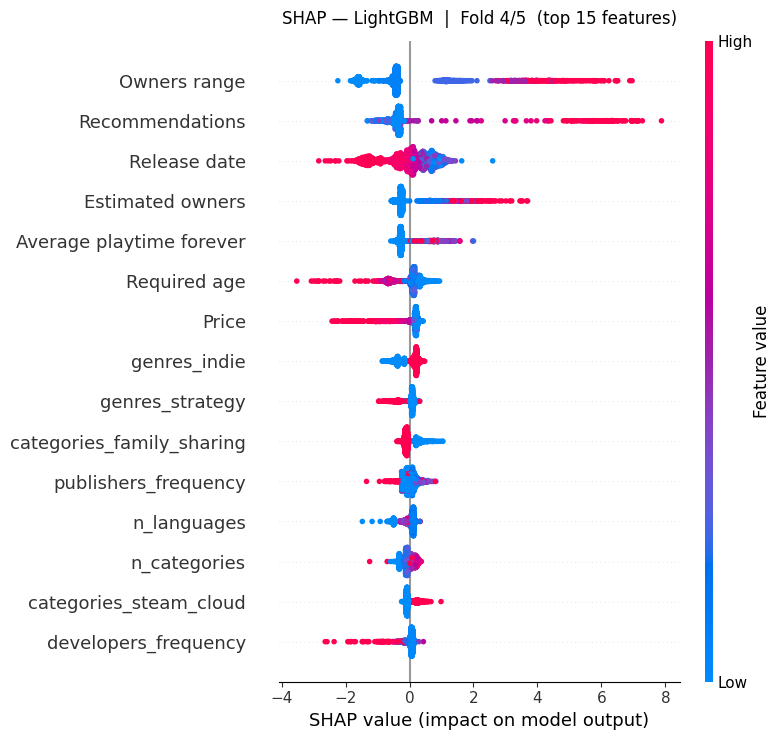


--- Fold 5/5 ---
  [LogReg (ElasticNet)] ...
  [LightGBM] ...
  [MLP] (30 epochs) ...
  Saved: results/klasyfikacja\cv_mlp_history_fold5.png


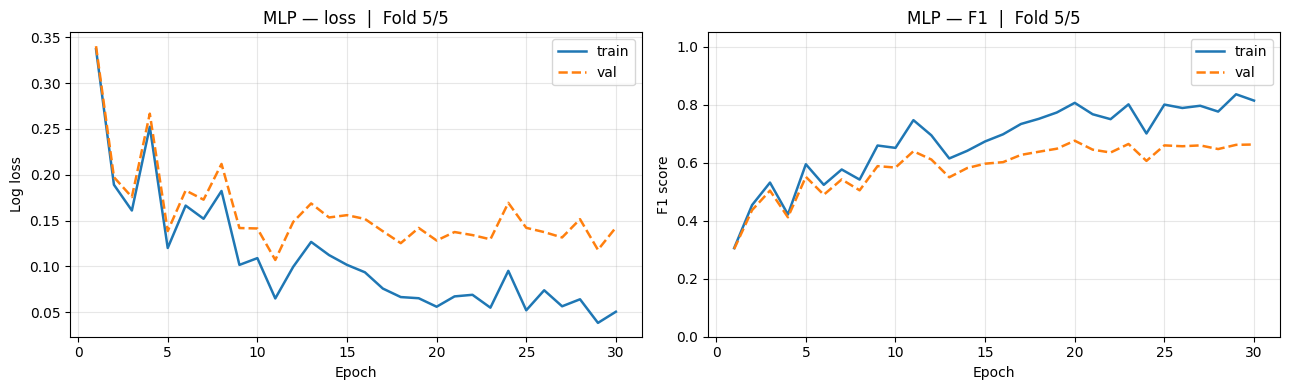

  Saved: results/klasyfikacja\cv_confusion_fold5.png


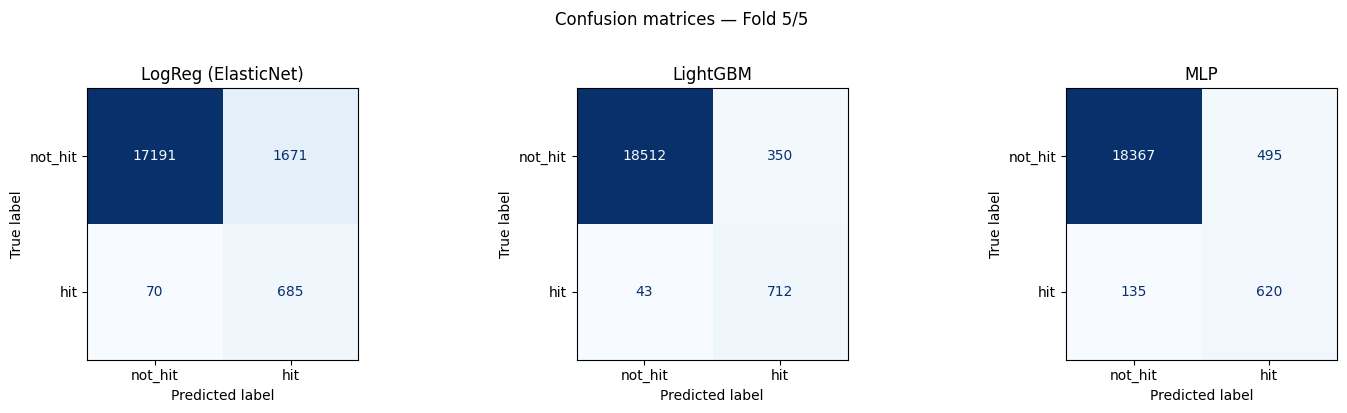

  Saved: results/klasyfikacja\cv_shap_fold5.png


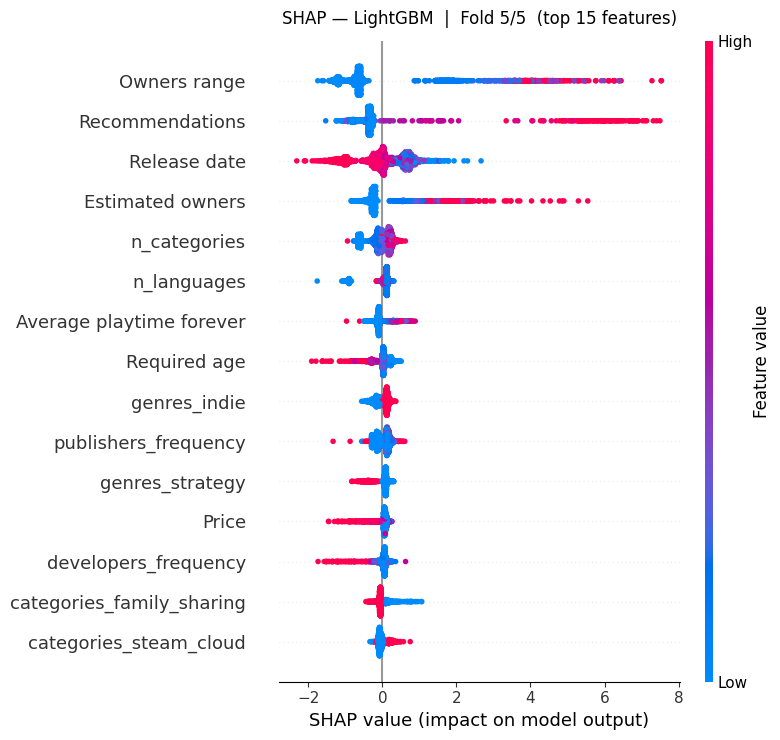

In [5]:
# Run 5-fold cross-validation for all three models
# This is the main training cell — expect it to take several minutes
cv_df = cross_validate_models(
    X_train, y_train,
    feature_names=feature_names,
    plot_fold_history=True,
    plot_fold_cm=True,
    plot_shap=True,
    X_test=X_test,
    y_test=y_test,
    save_dir=SAVE_DIR,
)

## 5. Save and Compare Results

In [6]:
cv_df.to_csv('csv_files/wyniki.csv')
print("Saved results to csv_files/wyniki.csv")

Saved results to csv_files/wyniki.csv


  Saved: results/klasyfikacja\cv_comparison_train_val_test.png


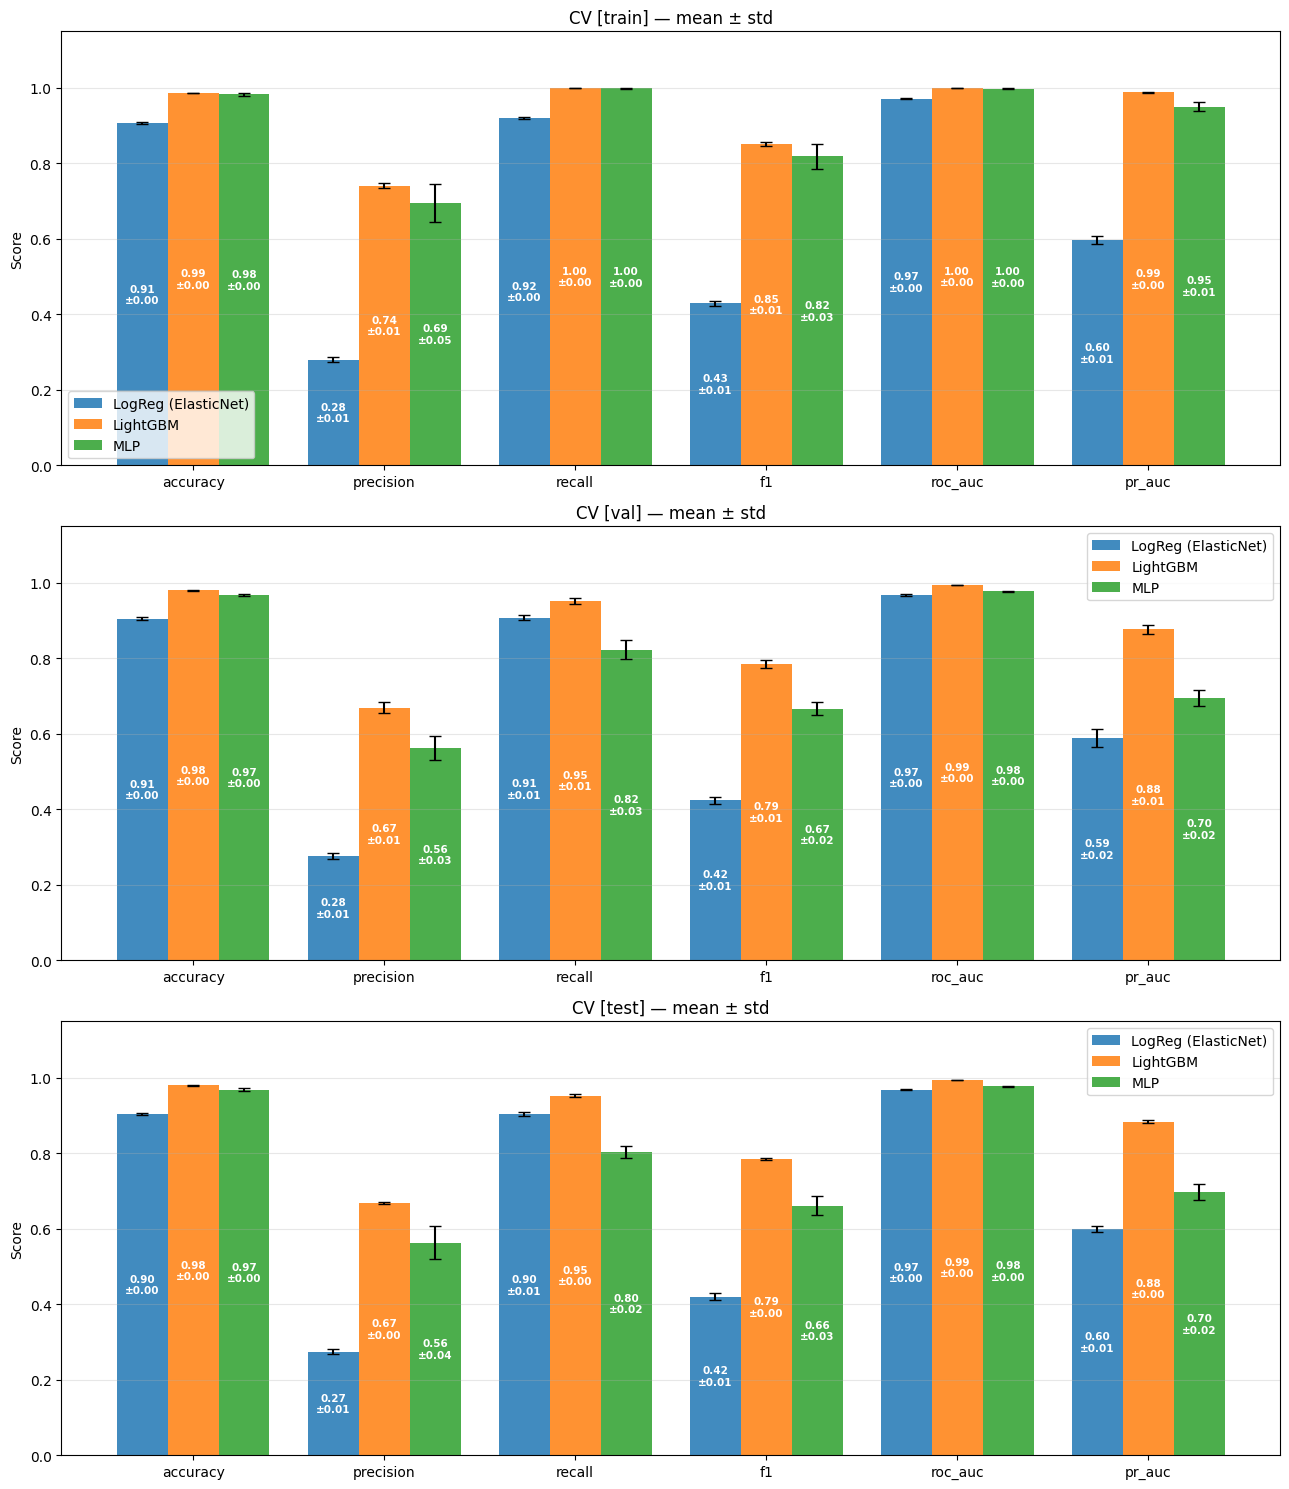

In [7]:
# Compare all three models across train, validation, and test splits
# For each split, six metrics are shown: accuracy, precision, recall, F1, ROC AUC, PR AUC
plot_cv_comparison(cv_df, splits=['train', 'val', 'test'], save_dir=SAVE_DIR)

### Reading the results

Each bar represents the mean ± std across 5 folds. Key things to look for:

- **PR AUC gap between train and val/test**: large gap → overfitting
- **Low recall on val/test**: model misses too many true hits
- **Low precision on val/test**: model generates too many false positives
- **Standard deviation**: large std → unstable model (sensitive to data split)

The **PR AUC** is the primary metric here. With ~4% positive class, ROC AUC is an optimistic indicator — a model can achieve high ROC AUC by correctly handling the overwhelming negative majority, without actually identifying hits well.

## 6. Feature Importance — SHAP & Stability Selection

### Why not just use per-fold SHAP?

SHAP values computed inside each cross-validation fold are dependent on the specific train/validation split. Features that rank highly in one fold may rank lower in another purely due to sampling variance.

### Stability Selection via Bootstrap

To identify a **stable** set of important features, we use bootstrap-based stability selection:

1. Repeat **30 iterations**: randomly draw 10,000 samples with replacement
2. Train a LightGBM model on each subsample
3. Compute SHAP values and select the top-20 features by mean |SHAP|
4. A feature is considered **stable** if it appears in the top-20 in **≥ 70%** of iterations

This approach is robust to any particular data split and identifies features that consistently matter across different views of the data.

  iteration 5/30 ...
  iteration 10/30 ...
  iteration 15/30 ...
  iteration 20/30 ...
  iteration 25/30 ...
  iteration 30/30 ...

Selected 15 stable features (>= 70% of 30 iterations).


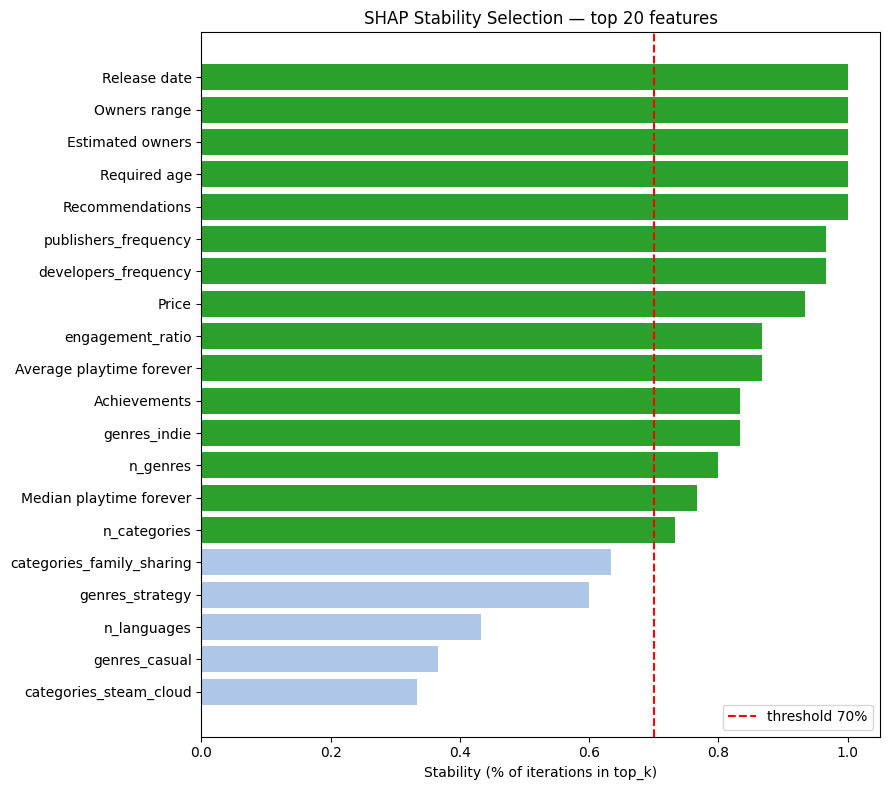


Stable features (15 total):
  Release date: 100%
  Owners range: 100%
  Estimated owners: 100%
  Required age: 100%
  Recommendations: 100%
  publishers_frequency: 97%
  developers_frequency: 97%
  Price: 93%
  engagement_ratio: 87%
  Average playtime forever: 87%
  Achievements: 83%
  genres_indie: 83%
  n_genres: 80%
  Median playtime forever: 77%
  n_categories: 73%


In [8]:
stability_scores, stable_features = shap_stability_selection(
    df_final,
    n_iterations=30,   # number of bootstrap iterations
    top_k=20,          # top-k features tracked per iteration
    threshold=0.7,     # feature must appear in >=70% of iterations to be "stable"
    sample_n=10000,    # subsample size (from 122k total — keeps runtime manageable)
)

print(f"\nStable features ({len(stable_features)} total):")
for feat in stable_features:
    print(f"  {feat}: {stability_scores[feat]:.0%}")

### Interpreting stability scores

A stability score of 100% means the feature appeared in the top-20 most important features in every single bootstrap iteration — it is consistently informative regardless of which 10k games were sampled.

Features below the 70% threshold are omitted: they appear important in some data slices but not others, suggesting their relationship with the target may be weaker or more context-dependent.

The stable feature list is the recommended starting point if you want to build a more interpretable or leaner version of the model.